In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("european.csv")
df.head(3)

,Unnamed: 0,Name,City,Cuisine Style,Ranking,Rating,Price Range,Number of Reviews,Reviews,URL_TA,ID_TA
0,0,Martine of Martine's Table,Amsterdam,"['French', 'Dutch', 'European']",1.0,5.0,$$ - $$$,136.0,"[['Just like home', 'A Warm Welcome to Wintry ...",/Restaurant_Review-g188590-d11752080-Reviews-M...,d11752080
1,1,De Silveren Spiegel,Amsterdam,"['Dutch', 'European', 'Vegetarian Friendly', '...",2.0,4.5,$$$$,812.0,"[['Great food and staff', 'just perfect'], ['0...",/Restaurant_Review-g188590-d693419-Reviews-De_...,d693419
2,2,La Rive,Amsterdam,"['Mediterranean', 'French', 'International', '...",3.0,4.5,$$$$,567.0,"[['Satisfaction', 'Delicious old school restau...",/Restaurant_Review-g188590-d696959-Reviews-La_...,d696959


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125527 entries, 0 to 125526
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         125527 non-null  int64  
 1   Name               125527 non-null  str    
 2   City               125527 non-null  str    
 3   Cuisine Style      94176 non-null   str    
 4   Ranking            115876 non-null  float64
 5   Rating             115897 non-null  float64
 6   Price Range        77672 non-null   str    
 7   Number of Reviews  108183 non-null  float64
 8   Reviews            115911 non-null  str    
 9   URL_TA             125527 non-null  str    
 10  ID_TA              125527 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 10.5 MB


## Cuisine Exploration

In [6]:
import ast

df['Cuisine Style'] = df['Cuisine Style'].dropna().apply(ast.literal_eval)
# 1. Explode the lists into individual rows and drop any missing values
flat_cuisines = df['Cuisine Style'].dropna().explode()

# 2. Strip any unexpected whitespaces just to be safe
flat_cuisines = flat_cuisines.astype(str).str.strip()

# 3. Calculate total unique count
unique_count = flat_cuisines.nunique()
print(f"✨ Total Unique Cuisines: {unique_count}\n")

# 4. Display the unique values alphabetically
print("📋 Unique Cuisines List:")
print(sorted(flat_cuisines.unique()))

✨ Total Unique Cuisines: 127

📋 Unique Cuisines List:
['Afghani', 'African', 'Albanian', 'American', 'Arabic', 'Argentinean', 'Armenian', 'Asian', 'Australian', 'Austrian', 'Azerbaijani', 'Balti', 'Bangladeshi', 'Bar', 'Barbecue', 'Belgian', 'Brazilian', 'Brew Pub', 'British', 'Burmese', 'Cafe', 'Cajun & Creole', 'Cambodian', 'Canadian', 'Caribbean', 'Caucasian', 'Central American', 'Central Asian', 'Central European', 'Chilean', 'Chinese', 'Colombian', 'Contemporary', 'Croatian', 'Cuban', 'Czech', 'Danish', 'Delicatessen', 'Diner', 'Dutch', 'Eastern European', 'Ecuadorean', 'Egyptian', 'Ethiopian', 'European', 'Fast Food', 'Filipino', 'French', 'Fujian', 'Fusion', 'Gastropub', 'Georgian', 'German', 'Gluten Free Options', 'Greek', 'Grill', 'Guatemalan', 'Halal', 'Hawaiian', 'Healthy', 'Hungarian', 'Indian', 'Indonesian', 'International', 'Irish', 'Israeli', 'Italian', 'Jamaican', 'Japanese', 'Korean', 'Kosher', 'Latin', 'Latvian', 'Lebanese', 'Malaysian', 'Mediterranean', 'Mexican', 'M

In [7]:
# Count how many times each cuisine appears
cuisine_counts = flat_cuisines.value_counts()

# Convert it to a beautiful summary DataFrame
cuisine_summary = cuisine_counts.to_frame(name='Restaurant Count')
cuisine_summary['Percentage Share (%)'] = (cuisine_summary['Restaurant Count'] / len(df)) * 100

print("📊 Cuisine Distribution Summary (Top 15):")
print("---------------------------------------------")
print(cuisine_summary.head(15))

📊 Cuisine Distribution Summary (Top 15):
---------------------------------------------
                     Restaurant Count  Percentage Share (%)
Cuisine Style                                              
Vegetarian Friendly             32361             25.780111
European                        30228             24.080875
Mediterranean                   18428             14.680507
Italian                         17795             14.176233
Vegan Options                   13009             10.363507
Gluten Free Options             12120              9.655293
Bar                              9690              7.719455
French                           9558              7.614298
Asian                            9064              7.220757
Pizza                            8317              6.625666
Spanish                          8220              6.548392
Pub                              7404              5.898333
Cafe                             7392              5.888773
Fast Food    

C:\Users\menes\AppData\Local\Temp\ipykernel_16864\129319136.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


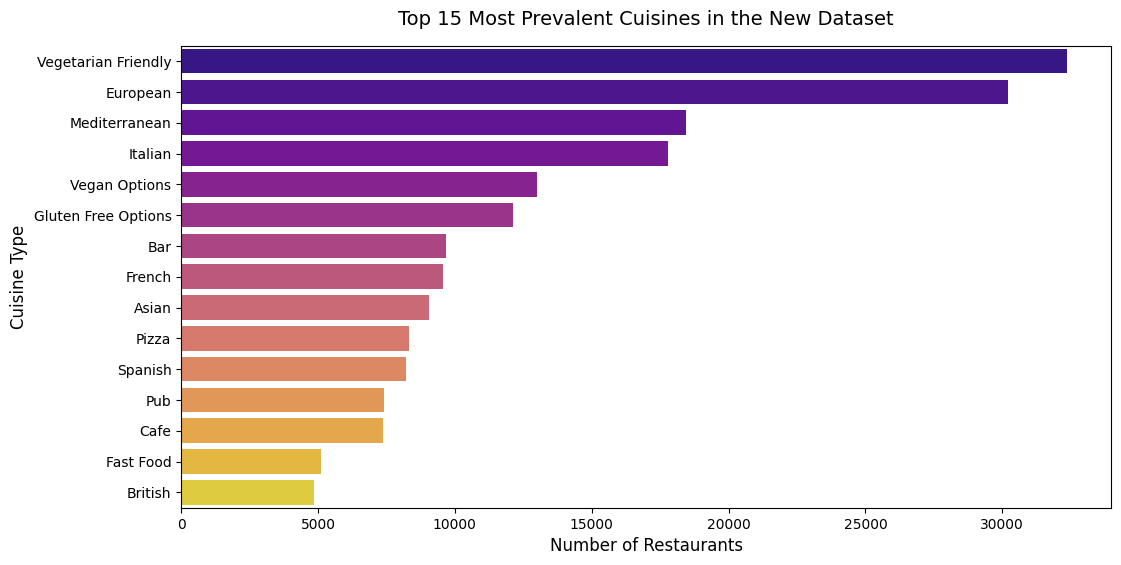

In [8]:
plt.figure(figsize=(12, 6))
# Plot the top 15 cuisines for readability
sns.barplot(
    x=cuisine_counts.head(15).values, 
    y=cuisine_counts.head(15).index, 
    palette="plasma"
)

plt.title("Top 15 Most Prevalent Cuisines in the New Dataset", fontsize=14, pad=15)
plt.xlabel("Number of Restaurants", fontsize=12)
plt.ylabel("Cuisine Type", fontsize=12)
plt.show()

## City Distribution

In [10]:
# 1. Count the number of restaurants per city
city_counts = df['City'].value_counts()

# 2. Convert to a beautiful summary DataFrame
city_summary = city_counts.to_frame(name='Restaurant Count')
city_summary['Percentage Share (%)'] = (city_summary['Restaurant Count'] / len(df)) * 100

print(f"Total Unique Cities in Dataset: {df['City'].nunique()}")
print("--------------------------------------------------")
print("Top 15 Cities by Density:")
print(city_summary.head(15))

Total Unique Cities in Dataset: 31
--------------------------------------------------
Top 15 Cities by Density:
           Restaurant Count  Percentage Share (%)
City                                             
London                18212             14.508432
Paris                 14874             11.849244
Madrid                 9543              7.602348
Barcelona              8425              6.711703
Berlin                 7078              5.638628
Milan                  6687              5.327141
Rome                   5949              4.739219
Prague                 4859              3.870880
Lisbon                 3986              3.175412
Vienna                 3724              2.966692
Amsterdam              3434              2.735666
Brussels               3204              2.552439
Hamburg                3131              2.494284
Munich                 2995              2.385941
Lyon                   2930              2.334159
